# NOAA18





In [1]:
import pandas as pd
import os
import numpy as np
import math
import pdb
import datetime
import matplotlib.pyplot as plt
from scipy.io import loadmat
from sklearn import metrics
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split

In [2]:
wd = os.getcwd() #working directory
fname_txt = 'matfile_NOAA18.mat'
fpath_txt = os.path.join(wd, fname_txt)
mat_data = loadmat(fpath_txt)

print(mat_data.keys())

variable_names = ['ConjDatenum', 'L', 'MLT', 'MLAT', 'MLAT_rbsp',
                  'NorthSouth', 'MLON', 'Lat_poes', 'Lon_poes',
                  'Poes90Flux','Poes90PA','Poes0Flux','Poes0PA','C', 'N','AE',
                  'AEsub0','AEsub1','AEsub2','AEsub3',
                  'AEsub4','AEsub5','AEsub6','AEsub7','AEsub8','AEsub9','AEsub10','AEsub11',
                  'AEsub12','AEsub13','AEsub14','AEsub15','AEsub16','AEsub17','AEsub18',
                  'AEsub19','AEsub20','AEsub21','AEsub22','AEsub23','AEsub24','AEsub25',
                  'AEsub26','AEsub27','AEsub28','AEsub29','AEsub30','AEsub31','AEsub32',
                  'AEsub33','AEsub34','AEsub35']


df_list= []
for var in variable_names:
    if var in mat_data:  # Check if the variable exists in the .mat file
        data = mat_data[var]
        df_list.append(pd.DataFrame(data, columns=[var]))  # Add variable data as a new column
        print(f"Converted {var} to DataFrame")
    else:
        print(f"{var} not found in the .mat file")

data_base = pd.concat(df_list, axis=1)
data_base["log_flux0"] = np.log10(data_base["Poes0Flux"])
data_base["log_flux90"] = np.log10(data_base["Poes90Flux"])
data_base.replace([np.inf, -np.inf], np.nan, inplace=True)
#drop every row where a NaN, inf exists: see https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.dropna.html
data_base.dropna(axis=0, inplace=True)

data_base

dict_keys(['__header__', '__version__', '__globals__', 'AE', 'AEsub0', 'AEsub1', 'AEsub10', 'AEsub11', 'AEsub12', 'AEsub13', 'AEsub14', 'AEsub15', 'AEsub16', 'AEsub17', 'AEsub18', 'AEsub19', 'AEsub2', 'AEsub20', 'AEsub21', 'AEsub22', 'AEsub23', 'AEsub24', 'AEsub25', 'AEsub26', 'AEsub27', 'AEsub28', 'AEsub29', 'AEsub3', 'AEsub30', 'AEsub31', 'AEsub32', 'AEsub33', 'AEsub34', 'AEsub35', 'AEsub4', 'AEsub5', 'AEsub6', 'AEsub7', 'AEsub8', 'AEsub9', 'C', 'ConjDatenum', 'L', 'Lat_poes', 'Lon_poes', 'MLAT', 'MLAT_rbsp', 'MLON', 'MLT', 'N', 'NorthSouth', 'Poes0Flux', 'Poes0PA', 'Poes90Flux', 'Poes90PA'])
Converted ConjDatenum to DataFrame
Converted L to DataFrame
Converted MLT to DataFrame
Converted MLAT to DataFrame
Converted MLAT_rbsp to DataFrame
Converted NorthSouth to DataFrame
Converted MLON to DataFrame
Converted Lat_poes to DataFrame
Converted Lon_poes to DataFrame
Converted Poes90Flux to DataFrame
Converted Poes90PA to DataFrame
Converted Poes0Flux to DataFrame
Converted Poes0PA to Data

,ConjDatenum,L,MLT,MLAT,MLAT_rbsp,NorthSouth,MLON,Lat_poes,Lon_poes,Poes90Flux,...,AEsub28,AEsub29,AEsub30,AEsub31,AEsub32,AEsub33,AEsub34,AEsub35,log_flux0,log_flux90
0,735508.707504,5.256038,15.738709,-64.529727,9.160426,0,55.232815,-68.759003,3.466000,8588.709961,...,241,163,107,127,148,184,197,122,2.207608,3.933928
1,735508.707527,5.223069,15.737154,-64.411627,9.159342,0,55.210476,-68.653999,3.318000,9072.581055,...,241,163,107,127,148,184,197,122,1.906578,3.957731
2,735508.707550,5.190277,15.735655,-64.292663,9.158256,0,55.188795,-68.547997,3.171000,6895.161133,...,241,163,107,127,148,184,197,122,1.906578,3.838544
3,735508.707573,5.157743,15.734156,-64.173768,9.157172,0,55.166887,-68.442001,3.025000,8185.483887,...,241,163,107,127,148,184,197,122,1.906578,3.913044
4,735508.707596,5.125739,15.732717,-64.055073,9.156087,0,55.145564,-68.335999,2.881000,7862.903320,...,241,163,107,127,148,184,197,122,2.207608,3.895583
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25114,737621.532127,2.806433,7.537870,-53.607202,4.768154,1,355.100540,-63.139000,280.920013,36411.289062,...,295,243,216,188,190,216,213,160,2.383700,4.561236
25115,737621.532150,2.819970,7.536442,-53.717916,4.764358,1,355.031369,-63.248001,280.821991,36411.289062,...,295,243,216,188,190,216,213,160,1.906578,4.561236
25116,737621.532174,2.832824,7.534977,-53.829678,4.760564,1,354.960942,-63.358002,280.721985,36411.289062,...,295,243,216,188,190,216,213,160,2.508638,4.561236
25117,737621.532197,2.845582,7.533505,-53.940455,4.756768,1,354.890694,-63.466999,280.622009,36411.289062,...,295,243,216,188,190,216,213,160,2.508638,4.561236


In [3]:
#Partition the training data
#from oct-2013

part1 = data_base.iloc[0:15486, :]
part2 = data_base.iloc[19286:, :]
data_training = pd.concat([part1, part2], axis=0)

data_testing = data_base.iloc[15486:19286,:]

print(data_training.shape)
print(data_testing.shape)


(21319, 54)
(3800, 54)


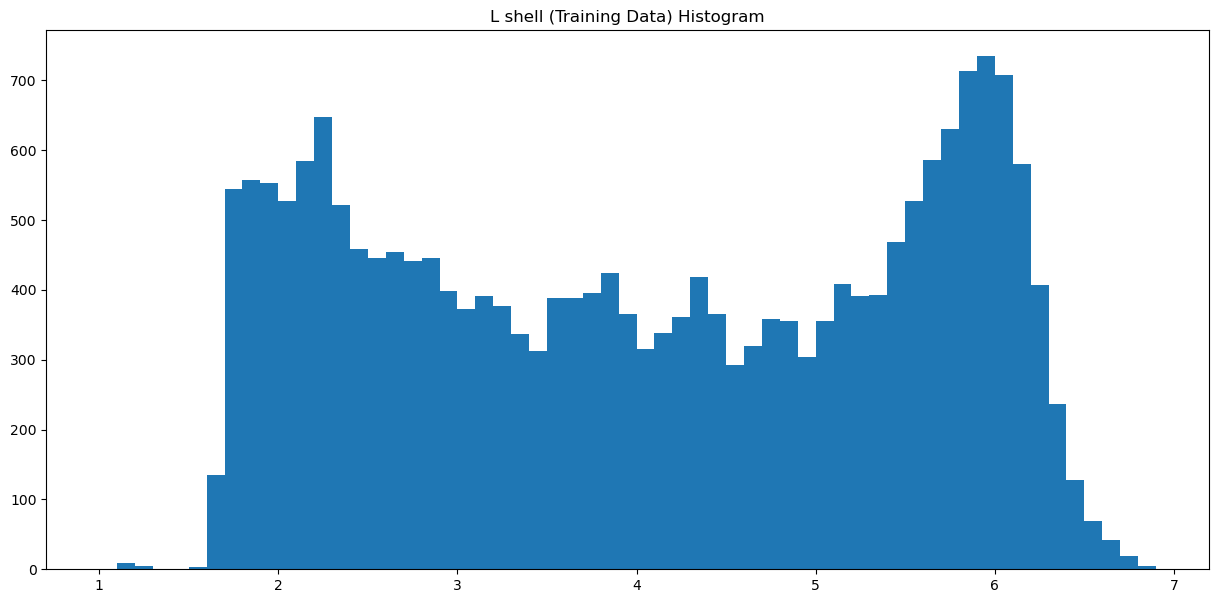

In [4]:
# Creating plot to show the spread in L shell
fig = plt.figure(figsize =(15, 7))
plt.hist(data_training["L"].values, bins=np.arange(1,7,0.1))
plt.title("L shell (Training Data) Histogram")
plt.show()

#**Establishing Train and Test data**
Create arrays: X_data(inputs), y_data(outputs)

In [5]:
X_data = data_training[["log_flux90", "log_flux0","L","MLT", "MLAT", "MLON","Lat_poes", "Lon_poes",
                         "AEsub0","AEsub1","AEsub2","AEsub3",
                         "AEsub4","AEsub5","AEsub6","AEsub7","AEsub8","AEsub9","AEsub10","AEsub11",
                         "AEsub12","AEsub13","AEsub14","AEsub15","AEsub16","AEsub17","AEsub18",
                         "AEsub19","AEsub20","AEsub21","AEsub22","AEsub23","AEsub24","AEsub25",
                         "AEsub26","AEsub27","AEsub28","AEsub29","AEsub30","AEsub31","AEsub32",
                         "AEsub33","AEsub34","AEsub35"]].values

y_data=data_training[["C","N"]].values

test_size = 0.3

X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=test_size, random_state=0)
# use the random_state argument to make sure results are deterministic

#**Training MLPRegressor**

In [6]:
# @title Build and train a the MLPR Model

scalerX = StandardScaler().fit(X_train)
X_train = scalerX.transform(X_train)
X_test = scalerX.transform(X_test)

regr_ann = MLPRegressor(random_state = 0, solver='adam', activation='relu',max_iter=1000,learning_rate_init= 0.001,
                        learning_rate = 'adaptive',hidden_layer_sizes = (100,100),verbose=False ) # random_state argument to make results deterministic

regr_ann.fit(X_train,y_train)
y_pred_ann = regr_ann.predict(X_test)

In [7]:
print('Held out, R2: ' ,metrics.r2_score(y_test, y_pred_ann))
print('In Sample, R2: ' ,metrics.r2_score(y_train, regr_ann.predict(X_train)))

Held out, R2:  0.9765087390830225
In Sample, R2:  0.9839799204055061


# **Testing**

In [8]:
# @title Loading Out of Sample POES data (2sec cadence), NOT conjunction based
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
fname_txt = 'NOAA18_May2017Feb2018.mat'
fpath_txt = os.path.join(wd, fname_txt)
val_data = loadmat(fpath_txt)


print(val_data.keys())

variable_names = ['L_runninglist', 'MLT_runninglist', 'MLAT_runninglist', 'MLON_runninglist',
                  'Lat_runninglist', 'Lon_runninglist', 'NorthSouth_runninglist',
                  'Flux90_runninglist','Flux0_runninglist',
                  "AEsub0","AEsub1","AEsub2","AEsub3",
                  "AEsub4","AEsub5","AEsub6","AEsub7","AEsub8","AEsub9","AEsub10","AEsub11",
                  "AEsub12","AEsub13","AEsub14","AEsub15","AEsub16","AEsub17","AEsub18",
                  "AEsub19","AEsub20","AEsub21","AEsub22","AEsub23","AEsub24","AEsub25",
                  "AEsub26","AEsub27","AEsub28","AEsub29","AEsub30","AEsub31","AEsub32",
                  "AEsub33","AEsub34","AEsub35", "Datenum_runninglist"]

df_list= []
for var in variable_names:
    if var in val_data:  # Check if the variable exists in the .mat file
        vardata = val_data[var]
        if vardata.shape[1] == 4:  # If vardata has 4 columns
          df_list.append(pd.DataFrame(vardata, columns=[f"{var}_1", f"{var}_2", f"{var}_3", f"{var}_4"]))
          print(f"Converted 4 {var} to DataFrame")
        else:
          df_list.append(pd.DataFrame(vardata, columns=[var]))  # Add variable data as a new column
          print(f"Converted {var} to DataFrame")
    else:
        print(f"{var} not found in the .mat file")

dataval_base = pd.concat(df_list, axis=1)
dataval_base["log_flux0"] = np.log10(dataval_base["Flux0_runninglist_1"])
dataval_base["log_flux90"] = np.log10(dataval_base["Flux90_runninglist_1"])
dataval_base["L"] = (dataval_base["L_runninglist"])
dataval_base["MLT"] = (dataval_base["MLT_runninglist"])
dataval_base["MLAT"] = (dataval_base["MLAT_runninglist"])
dataval_base["MLON"] = (dataval_base["MLON_runninglist"])
dataval_base["Lat_poes"] = (dataval_base["Lat_runninglist"])
dataval_base["Lon_poes"] = (dataval_base["Lon_runninglist"])
dataval_base.replace([np.inf, -np.inf], np.nan, inplace=True)
#drop every row where a NaN, inf exists: see https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.dropna.html
dataval_base.dropna(axis=0, inplace=True)


dict_keys(['__header__', '__version__', '__globals__', 'AE_runninglist', 'AEstar3hravg_runninglist', 'AEstar3hrmax_runninglist', 'AEstar3hrmin_runninglist', 'AEsub0', 'AEsub1', 'AEsub10', 'AEsub11', 'AEsub12', 'AEsub13', 'AEsub14', 'AEsub15', 'AEsub16', 'AEsub17', 'AEsub18', 'AEsub19', 'AEsub2', 'AEsub20', 'AEsub21', 'AEsub22', 'AEsub23', 'AEsub24', 'AEsub25', 'AEsub26', 'AEsub27', 'AEsub28', 'AEsub29', 'AEsub3', 'AEsub30', 'AEsub31', 'AEsub32', 'AEsub33', 'AEsub34', 'AEsub35', 'AEsub4', 'AEsub5', 'AEsub6', 'AEsub7', 'AEsub8', 'AEsub9', 'BoverBeq_poes_runninglist', 'Datenum_runninglist', 'Flux0_runninglist', 'Flux90_runninglist', 'L_runninglist', 'Lat_runninglist', 'Lon_runninglist', 'MLAT_runninglist', 'MLON_runninglist', 'MLT_runninglist', 'NorthSouth_runninglist', 'PA0_runninglist', 'PA90_runninglist'])
Converted L_runninglist to DataFrame
Converted MLT_runninglist to DataFrame
Converted MLAT_runninglist to DataFrame
Converted MLON_runninglist to DataFrame
Converted Lat_runninglist 

In [9]:
## NOT on conjunction basis
X_data_testing = dataval_base[["log_flux90", "log_flux0","L","MLT","MLAT", "MLON","Lat_poes", "Lon_poes",
                               "AEsub0","AEsub1","AEsub2","AEsub3",
                               "AEsub4","AEsub5","AEsub6","AEsub7","AEsub8","AEsub9","AEsub10","AEsub11",
                               "AEsub12","AEsub13","AEsub14","AEsub15","AEsub16","AEsub17","AEsub18",
                               "AEsub19","AEsub20","AEsub21","AEsub22","AEsub23","AEsub24","AEsub25",
                               "AEsub26","AEsub27","AEsub28","AEsub29","AEsub30","AEsub31","AEsub32",
                               "AEsub33","AEsub34","AEsub35"]].values

y_pred_test = regr_ann.predict(scalerX.transform(X_data_testing))
data_to_save = {'ALL_C': y_pred_test[:,0], 'ALL_N': y_pred_test[:,1]}
filename = f"outputs_test_NOAA15.mat"
#savemat(filename, data_to_save)

In [10]:
## IS ON on conjunction basis
X_data_validation = data_testing[["log_flux90", "log_flux0","L","MLT", "MLAT", "MLON","Lat_poes", "Lon_poes",
                         "AEsub0","AEsub1","AEsub2","AEsub3",
                         "AEsub4","AEsub5","AEsub6","AEsub7","AEsub8","AEsub9","AEsub10","AEsub11",
                         "AEsub12","AEsub13","AEsub14","AEsub15","AEsub16","AEsub17","AEsub18",
                         "AEsub19","AEsub20","AEsub21","AEsub22","AEsub23","AEsub24","AEsub25",
                         "AEsub26","AEsub27","AEsub28","AEsub29","AEsub30","AEsub31","AEsub32",
                         "AEsub33","AEsub34","AEsub35"]].values
y_pred_val = regr_ann.predict(scalerX.transform(X_data_validation))
data_to_save = {'C_conj': y_pred_val[:,0], 'N_conj': y_pred_val[:,1]}
filename = f"outputs_val_NOAA15.mat"
#savemat(filename, data_to_save)